In [1]:
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from skrebate import ReliefF

In [2]:
data = np.load('../data/oversampled_data.npy', allow_pickle=True)
gene = np.load('../data/geneAfterDiscard_0.npy', allow_pickle=True)

feature = data[:, :-1]
label = data[:, -1]
print(gene.shape)
print(feature.shape)
print(label.shape)

(11959,)
(296, 11959)
(296,)


In [3]:
# repeated experiments
runNum = 100

imp = []
tic = time.time()

for i in range(runNum):
    # Make sure to compute the feature importance scores from only your training set
    X_train, X_test, y_train, y_test = train_test_split(feature, label, test_size=0.3, shuffle=True)
    fs = ReliefF()
    fs.fit(X_train, y_train)
    imp.append(fs.feature_importances_)
    print(i, fs.feature_importances_.sum())

toc = time.time()
duration = toc-tic
print(f'duration:{duration}')

In [4]:
# calculating feature importance

imp = np.array(imp)

"""
Because the characteristics of each experiment are not equal in importance, 
in order to ensure the equality of each experiment,
Here, the sum of the characteristic importance of each experiment is 1
"""

for i in range(imp.shape[0]):
    rowSum = imp[i].sum()
    imp[i] /= rowSum

np.save("NormalizedImp100.npy", imp)

#  Select signature gene

In [5]:
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [6]:
allImp = np.load("NormalizedImp100.npy")
gene = np.load('../data/geneAfterDiscard_0.npy', allow_pickle=True)

impSum = allImp.sum(axis = 0)

geneIdx = [i for i in range(gene.shape[0])]

# Importance ranking
toSort = zip(geneIdx, impSum)
sortedImp = sorted(toSort, key=lambda x: x[1], reverse=1)

sortedImp = np.array(list(zip(*sortedImp)))

sortedIdx = sortedImp[0].astype(int)
print(sortedIdx.shape)
print(sortedIdx)

(11959,)
[ 3774 10578  7189 ... 11208  6763  6609]


In [8]:
data = np.load('../data/oversampled_data.npy', allow_pickle=True)

feature = data[:, :-1]
label = data[:, -1]
print(gene.shape)
print(feature.shape)
print(label.shape)

(11959,)
(296, 11959)
(296,)


# Random Forest classification test

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

In [10]:
times = 100
geneNum = np.arange(1, times + 1)

In [19]:
acc = []
prec = []
rec = []
f1 = []
auc = []


X_train, X_test, y_train, y_test = train_test_split(feature, label, test_size=0.3, shuffle=True, random_state=2022)

for i in range(1, times + 1):
     # get genes
    xTrain = X_train[:, sortedIdx[:i]]
    xTest = X_test[:, sortedIdx[:i]]

    allAcc = []
    allPrec = []
    allRec = []
    allF1 = []
    allAuc = []

    for _ in range(5):
        rf = RandomForestClassifier(n_jobs = 8)
        rf.fit(xTrain, y_train)  
        y_pred = rf.predict(xTest)

        allAcc.append(accuracy_score(y_test, y_pred))
        allPrec.append(precision_score(y_test, y_pred))
        allRec.append(recall_score(y_test, y_pred))
        allF1.append(f1_score(y_test, y_pred))
        predict_prob_y = rf.predict_proba(xTest)[:, 1]
        allAuc.append(roc_auc_score(y_test, predict_prob_y))


    acc.append(np.array(allAcc).mean())
    prec.append(np.array(allPrec).mean())
    rec.append(np.array(allRec).mean())
    f1.append(np.array(allF1).mean())
    auc.append(np.array(allAuc).mean())


geneNum = np.array(geneNum)
acc = np.array(acc)
prec = np.array(prec)
rec = np.array(rec)
f1 = np.array(f1)
auc = np.array(auc)

In [12]:
geneNum = np.array(geneNum)
acc = np.array(acc)
prec = np.array(prec)
rec = np.array(rec)
f1 = np.array(f1)
auc = np.array(auc)

path = "performance/"

np.save(path + "ReliefF_acc.npy", acc)
np.save(path + "ReliefF_prec.npy", prec)
np.save(path + "ReliefF_rec.npy", rec)
np.save(path + "ReliefF_f1.npy", f1)
np.save(path + "ReliefF_auc.npy", auc)

In [11]:
path = "performance/"

acc = np.load(path + "ReliefF_acc.npy")
prec = np.load(path + "ReliefF_prec.npy")
rec = np.load(path + "ReliefF_rec.npy")
f1 = np.load(path + "ReliefF_f1.npy")
auc = np.load(path + "ReliefF_auc.npy")

In [13]:
bar = 100

print(acc[:bar].argmax(), acc[acc[:bar].argmax()])
print(prec[:bar].argmax(), prec[prec[:bar].argmax()])
print(rec[:bar].argmax(), rec[rec[:bar].argmax()])
# print(f1[:bar].argmax(), f1[f1[:bar].argmax()])
print(auc[:bar].argmax(), auc[auc[:bar].argmax()])

idxList = np.array([acc[:bar].argmax(), f1[:bar].argmax(), auc[:bar].argmax()])
satisfiedIdx = np.where(idxList<bar) # Select the number of satisfactory signature genes
SGnum = idxList[satisfiedIdx].max() + 1
SGnum

59 0.9348314606741572
43 0.9144444444444444
59 0.9627906976744185
51 0.9844792719919111


60

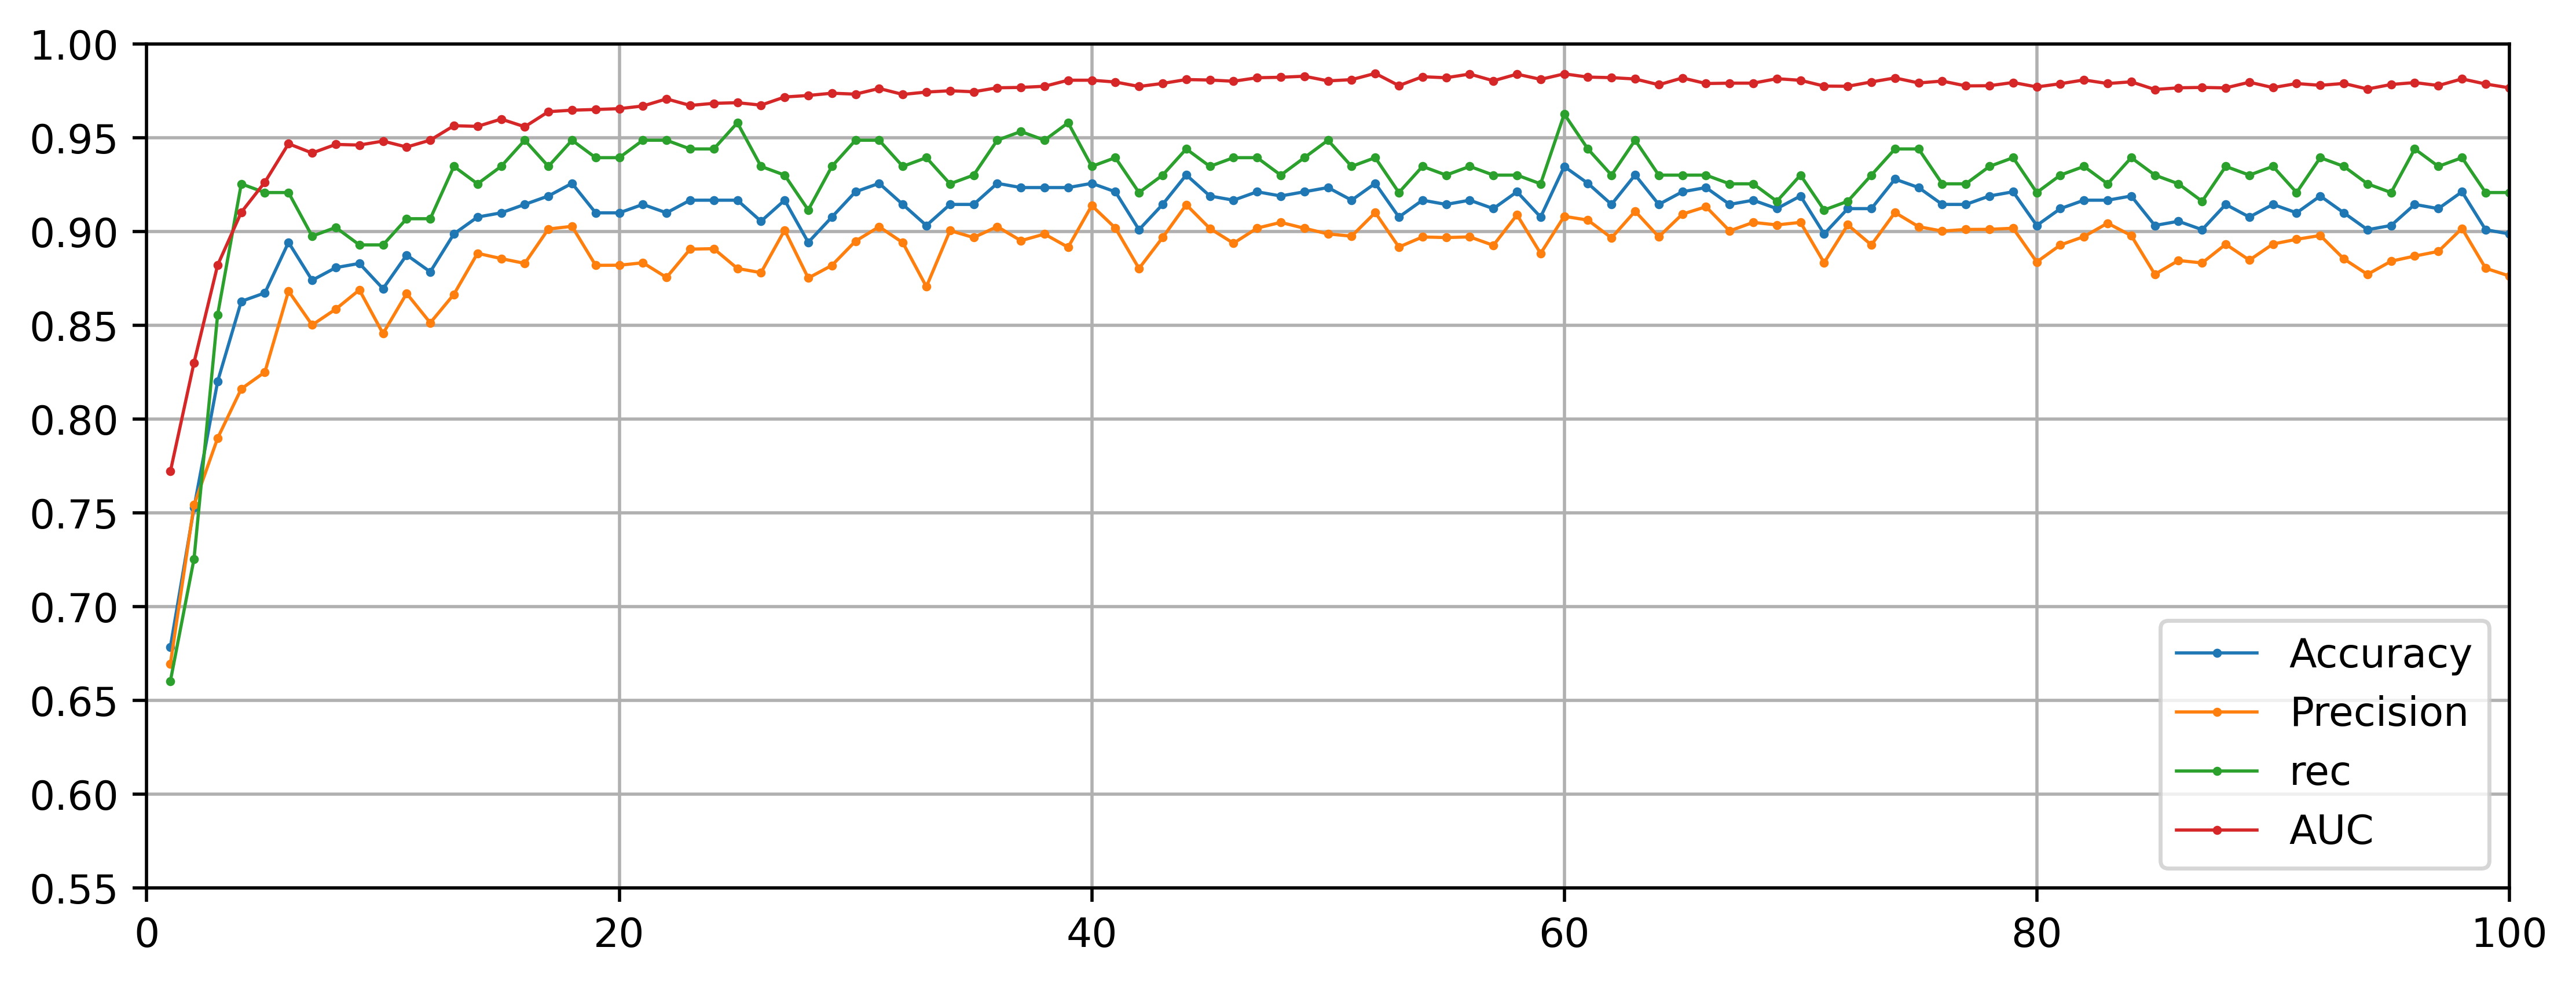

In [26]:
from matplotlib.pyplot import MultipleLocator

pointnum = bar
x_axi = geneNum[:pointnum]
plt.figure(figsize=(9, 3.5), dpi=500)
plt.xlim(0, pointnum, 50)
plt.ylim(0.55, 1)

markersize = 2.5
linewidth = 0.8

plt.plot(x_axi, acc[:pointnum], '.-',label='Accuracy', markersize= markersize, linewidth = linewidth)
plt.plot(x_axi, prec[:pointnum], '.-',label='Precision', markersize= markersize, linewidth = linewidth)
plt.plot(x_axi, rec[:pointnum], '.-',label='rec', markersize= markersize, linewidth = linewidth)
# plt.plot(x_axi, f1[:pointnum], '.-',label='F1-score', markersize= markersize, linewidth = linewidth)
plt.plot(x_axi, auc[:pointnum], '.-',label='AUC', markersize= markersize, linewidth = linewidth)

# plt.vlines(SGnum, 0.55, 1., colors='k', linestyles='--', alpha=0.8, label=f'Num={SGnum}')

plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
# plt.savefig('SGselect.eps', format='eps', dpi=300)
plt.savefig(f'ReliefF{pointnum}.jpg', format='jpg', dpi=300)

In [15]:
check_point = 59
acc[check_point], prec[check_point], rec[check_point], auc[check_point]

(0.9348314606741572,
 0.9082548893187191,
 0.9627906976744185,
 0.9842264914054599)

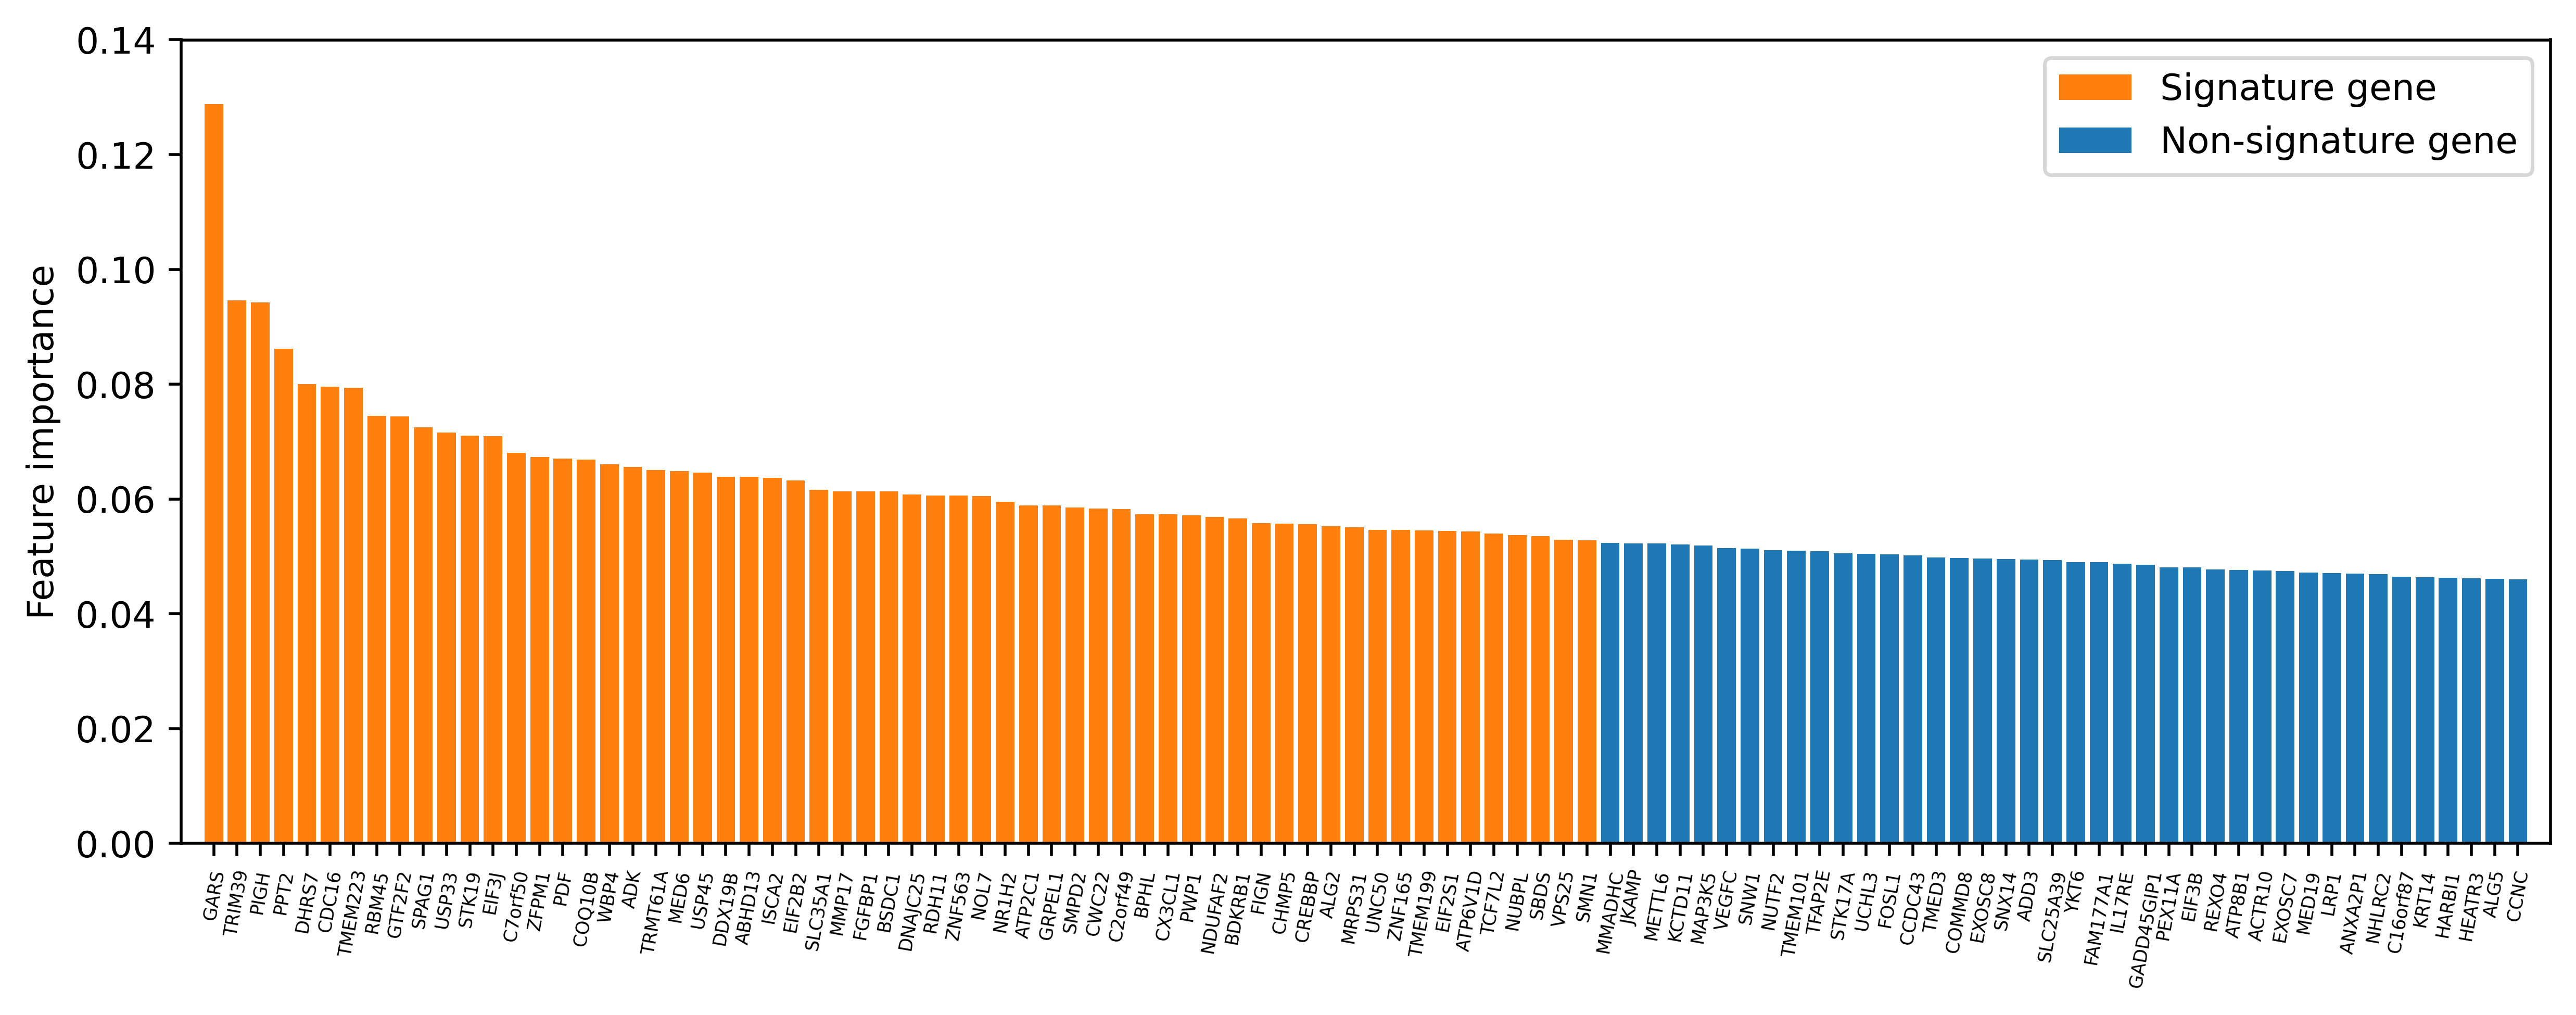

In [27]:
# Draw the importance of feature
SG = gene[sortedIdx][:SGnum]
SGimp = sortedImp[1, :SGnum]
left1 = np.arange(SGnum) + 1

nonSGnum = 40
nonSG = gene[sortedIdx][SGnum : SGnum + nonSGnum]
nonSGimp = sortedImp[1, SGnum : SGnum + nonSGnum]
left2 = np.arange(SGnum, SGnum + nonSGnum) + 1

fig = plt.figure(figsize=(10, 4), dpi=500)

ax = fig.add_subplot(111)

plt.bar(left2, nonSGimp, label = "Non-signature gene")
plt.bar(left1, SGimp, label = "Signature gene") #color  

locs, labs = plt.xticks(np.append(left1,left2), np.append(SG, nonSG), rotation=80, fontsize=5)

ax.set_ylim(0, 0.14)

plt.ylabel("Feature importance")
plt.margins(0.01)

# plt.legend(loc='upper right')

handles,labels = ax.get_legend_handles_labels()

handles = [handles[1], handles[0]]
labels = [labels[1], labels[0]]

ax.legend(handles,labels,loc='upper right',)

plt.tight_layout()

# plt.savefig('impCompare.eps', format='eps', dpi=1000)
plt.savefig('featureImpSum.jpg', format='jpg', dpi=500)